# Sequence Processing with HMMs and CRFs

**The goal of this practical is to study sequence models in NLP.**

We will work on Part-Of-Speech (POS) and optionally on chunking (gathering different groups in sentences). The datasets are from [CONLL 2000](https://www.clips.uantwerpen.be/conll2000/chunking/): 
- **Small corpus:** chtrain/chtest to understand the tools and models 
- **Larger corpus:** train/test to collect reliable experimental results


# 1) HMMS


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Loading POS/Chunking data
def load(filename):
    listeDoc = list()
    with open(filename, "r") as f:
        doc = list()
        for ligne in f:
            if len(ligne) < 2: # fin de doc
                listeDoc.append(doc)
                doc = list()
                continue
            mots = ligne.replace("\n","").split(" ")
            doc.append((mots[0],mots[1])) # Change mots[1] -> mots[2] for chuncking
    return listeDoc

In [3]:
# =============== loding ============
# small corpus => ideal for first tests
filename = "./conll2000/chtrain.txt" 
filenameT = "./conll2000/chtest.txt" 

# Larger corpus => To valide perf.
# filename = "ressources/conll2000/train.txt" 
# filenameT = "ressources/conll2000/test.txt" 

alldocs = load(filename)
alldocsT = load(filenameT)

print(len(alldocs)," docs read")
print(len(alldocsT)," docs (T) read")

823  docs read
77  docs (T) read


In [4]:
print(alldocs[0])
print(alldocsT[0])

[('Rockwell', 'NNP'), ('International', 'NNP'), ('Corp.', 'NNP'), ("'s", 'POS'), ('Tulsa', 'NNP'), ('unit', 'NN'), ('said', 'VBD'), ('it', 'PRP'), ('signed', 'VBD'), ('a', 'DT'), ('tentative', 'JJ'), ('agreement', 'NN'), ('extending', 'VBG'), ('its', 'PRP$'), ('contract', 'NN'), ('with', 'IN'), ('Boeing', 'NNP'), ('Co.', 'NNP'), ('to', 'TO'), ('provide', 'VB'), ('structural', 'JJ'), ('parts', 'NNS'), ('for', 'IN'), ('Boeing', 'NNP'), ("'s", 'POS'), ('747', 'CD'), ('jetliners', 'NNS'), ('.', '.')]
[('Confidence', 'NN'), ('in', 'IN'), ('the', 'DT'), ('pound', 'NN'), ('is', 'VBZ'), ('widely', 'RB'), ('expected', 'VBN'), ('to', 'TO'), ('take', 'VB'), ('another', 'DT'), ('sharp', 'JJ'), ('dive', 'NN'), ('if', 'IN'), ('trade', 'NN'), ('figures', 'NNS'), ('for', 'IN'), ('September', 'NNP'), (',', ','), ('due', 'JJ'), ('for', 'IN'), ('release', 'NN'), ('tomorrow', 'NN'), (',', ','), ('fail', 'VB'), ('to', 'TO'), ('show', 'VB'), ('a', 'DT'), ('substantial', 'JJ'), ('improvement', 'NN'), ('from'

## Building a baseline POS model (without sequence)

We will build a simple dictionary ```word => PoS label``` without taking into account any sequence information. We will compare the sequence models to this baseline.

The dataset is a list a tuples with ```(word, POS)```. **Build a simple dictionary mapping each word to its PoS tag in the train set**

In [5]:
from collections import defaultdict, Counter

# word -> Counter of POS tags
counts = defaultdict(Counter)

for doc in alldocs:
    for word, pos in doc:
        counts[word][pos] += 1

print(counts['International'])

dico = {}

for word, counter in counts.items():
    dico[word] = counter.most_common(1)[0][0]

Counter({'NNP': 2, 'JJ': 1})


**Note: on the test set, there are unknown words...**. We will use the following simple strategy: 
```
# remplace
dico[cle] # crashing with an unknown key 
# by 
dico.get(cle, DefaultValue)
```
From a linguistic point of view, we can choose the default value as the majority PoS class, producing a stronger baseline.

In [6]:
# count all POS tags in training data
pos_counts = Counter(
    pos for doc in alldocs for _, pos in doc
)

DefaultValue = pos_counts.most_common(1)[0][0]
print("Default PoS:", DefaultValue)

Default PoS: NN


In [7]:
correct = 0
total = 0

for doc in alldocsT:
    for word, pos in doc:
        pred = dico.get(word, DefaultValue)
        if pred == pos:
            correct += 1
        total += 1

print(f"{correct} good predictions in test over {total}")


1549 good predictions in test over 1896


Check: 1433 good predictions in test over 1896

(1527 with 'NN' as default PoS value)

## HMMs

Here is a code for training HMM parameters and running decoding using the Viterbi algorithm. You should apply it to our PoS task. **N.B.: you should undersand the ```eps``` parmaters**.


In [8]:
# allx: list of observation sequences 
# allq: list os state sequences 
# N: nb states
# K: nb observations

def learnHMM(allx, allq, N, K, initTo1=True):
    if initTo1:
        eps = 1e-1 # You can play with this regularization parameter 
        A = np.ones((N,N))*eps
        B = np.ones((N,K))*eps
        Pi = np.ones(N)*eps
    else:
        A = np.zeros((N,N))
        B = np.zeros((N,K))
        Pi = np.zeros(N)
    for x,q in zip(allx,allq):
        Pi[int(q[0])] += 1
        for i in range(len(q)-1):
            A[int(q[i]),int(q[i+1])] += 1
            B[int(q[i]),int(x[i])] += 1
        B[int(q[-1]),int(x[-1])] += 1 # last transition
    A = A/np.maximum(A.sum(1).reshape(N,1),1) # normalisation
    B = B/np.maximum(B.sum(1).reshape(N,1),1) # normalisation
    Pi = Pi/Pi.sum()
    return Pi , A, B

def viterbi(x,Pi,A,B):
    T = len(x)
    N = len(Pi)
    logA = np.log(A)
    logB = np.log(B)
    logdelta = np.zeros((N,T))
    psi = np.zeros((N,T), dtype=int)
    S = np.zeros(T)
    logdelta[:,0] = np.log(Pi) + logB[:,int(x[0])]
    #forward
    for t in range(1,T):
        logdelta[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).max(0) + logB[:,int(x[t])]
        psi[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).argmax(0)
    # backward
    logp = logdelta[:,-1].max()
    S[T-1] = logdelta[:,-1].argmax()
    for i in range(2,T+1):
        S[int(T-i)] = psi[int(S[int(T-i+1)]),int(T-i+1)]
    return S, logp #, delta, psi
 

### Data encoding

We will map each word to an index for traing the HMM (see code below):
```
 The cat is in the garden => 1 2 3 4 1 5
```
We have to understand the dictionary functionning to retrieve the words corresponding to indices.

In [9]:
# alldocs etant issu du chargement des données
# la mise en forme des données est fournie ici
# afin de produire des analyses qualitative, vous devez malgré tout comprendre le fonctionnement des dictionnaires

buf = [[m for m,pos in d ] for d in alldocs]
mots = []
[mots.extend(b) for b in buf]
mots = np.unique(np.array(mots))
nMots = len(mots)+1 # mot inconnu
print("mots: ", mots)

mots2ind = dict(zip(mots,range(len(mots))))
mots2ind["UUUUUUUU"] = len(mots)
print("mots2ind: ", mots2ind)

buf2 = [[pos for m,pos in d ] for d in alldocs]
cles = []
[cles.extend(b) for b in buf2]
cles = np.unique(np.array(cles))
cles2ind = dict(zip(cles,range(len(cles))))
print("cles2ind: ", cles2ind)

nCles = len(cles)

print(nMots,nCles," in the dictionary")

# mise en forme des données
allx  = [[mots2ind[m] for m,pos in d] for d in alldocs] # list of lists of word indices for training
                                                        # list of word indices per sentence in training
allxT = [[mots2ind.setdefault(m,len(mots)) for m,pos in d] for d in alldocsT]

allq  = [[cles2ind[pos] for m,pos in d] for d in alldocs] # list of lists of POS indices for training
                                                          # list of POS indices per sentence in training
allqT = [[cles2ind.setdefault(pos,len(cles)) for m,pos in d] for d in alldocsT]

print("allx: ", allx)
print("allq: ", allq)
print(mots2ind['International'])

mots:  ['!' '$' '%' ... 'younger' 'your' 'youthful']
mots2ind:  {np.str_('!'): 0, np.str_('$'): 1, np.str_('%'): 2, np.str_('&'): 3, np.str_("'"): 4, np.str_("''"): 5, np.str_("'S"): 6, np.str_("'d"): 7, np.str_("'ll"): 8, np.str_("'m"): 9, np.str_("'re"): 10, np.str_("'s"): 11, np.str_("'ve"): 12, np.str_(','): 13, np.str_('-'): 14, np.str_('--'): 15, np.str_('-LCB-'): 16, np.str_('-LRB-'): 17, np.str_('-RCB-'): 18, np.str_('-RRB-'): 19, np.str_('.'): 20, np.str_('...'): 21, np.str_('0.1'): 22, np.str_('0.2'): 23, np.str_('0.3'): 24, np.str_('0.4'): 25, np.str_('0.5'): 26, np.str_('1'): 27, np.str_('1,000'): 28, np.str_('1,040'): 29, np.str_('1,050'): 30, np.str_('1,174'): 31, np.str_('1,200'): 32, np.str_('1.02'): 33, np.str_('1.03'): 34, np.str_('1.045'): 35, np.str_('1.05'): 36, np.str_('1.1'): 37, np.str_('1.11'): 38, np.str_('1.15'): 39, np.str_('1.2'): 40, np.str_('1.20'): 41, np.str_('1.27'): 42, np.str_('1.29'): 43, np.str_('1.3'): 44, np.str_('1.375'): 45, np.str_('1.40'): 46

In [10]:
# First doc:
print(allx[0])
print(allq[0])

[1140, 814, 563, 11, 1294, 4393, 3855, 2854, 3992, 1362, 4242, 1452, 2395, 2855, 1990, 4529, 446, 525, 4299, 3595, 4148, 3368, 2499, 446, 11, 283, 2861, 20]
[18, 18, 18, 22, 18, 17, 32, 23, 32, 9, 13, 17, 33, 24, 17, 12, 18, 18, 29, 31, 13, 20, 12, 18, 22, 8, 20, 5]


## You turn: apply HMMs to those data!

In [11]:
Pi, A, B = learnHMM(allx, allq, N=nCles, K=nMots, initTo1=True)

In [12]:
correct = 0
total = 0

for x_seq, q_seq in zip(allxT, allqT):
    S_hat, logp = viterbi(x_seq, Pi, A, B)
    S_hat = S_hat.astype(int)
    q_seq = np.array(q_seq).astype(int)
    correct += np.sum(S_hat == q_seq)
    total += len(q_seq)

accuracy = correct / total
print(f"HMM test accuracy: {accuracy:.4f} ({correct} / {total})")

HMM test accuracy: 0.8254 (1565 / 1896)


Check : 1564 in test

### Qualitative Analyis:

- With imshow on the parameters (ou d'un argsort), show what are the probable transition between labels.
- Visualize the confusion matrices to understand what is challenging in this task
- Find out examples that are corrected by Viterbi decoding



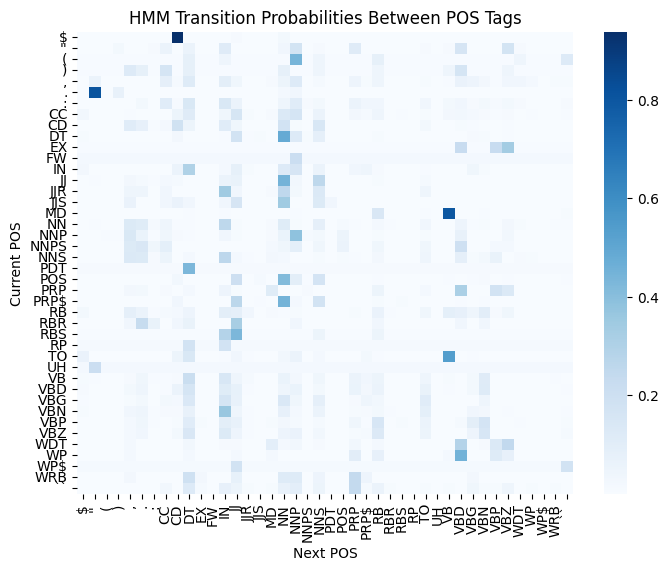

In [13]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(A, annot=False, xticklabels=cles, yticklabels=cles, cmap="Blues", cbar=True)
plt.title("HMM Transition Probabilities Between POS Tags")
plt.xlabel("Next POS")
plt.ylabel("Current POS")
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for x_seq, q_seq in zip(allxT, allqT):
    S_hat, _ = viterbi(x_seq, Pi, A, B)
    y_true.extend(q_seq)
    y_pred.extend(S_hat.astype(int))

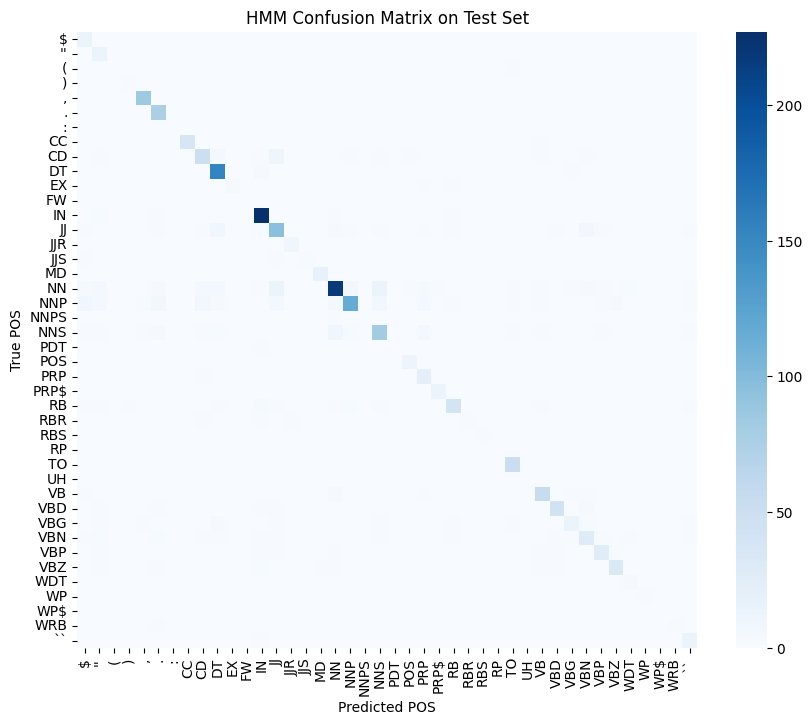

In [15]:
cm = confusion_matrix(y_true, y_pred, labels=range(nCles))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cles)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=cles, yticklabels=cles)
plt.title("HMM Confusion Matrix on Test Set")
plt.xlabel("Predicted POS")
plt.ylabel("True POS")
plt.show()

In [16]:
corrected_examples = []

for x_seq, q_seq in zip(allxT, allqT):
    S_hat, _ = viterbi(x_seq, Pi, A, B)
    for idx, (word_idx, true_idx) in enumerate(zip(x_seq, q_seq)):
        word = mots[word_idx] if word_idx < len(mots) else "UNK"
        true_pos = cles[true_idx-1]
        baseline_pred = dico.get(word, DefaultValue)
        hmm_pred = cles[int(S_hat[idx])]
        
        if baseline_pred != true_pos and hmm_pred == true_pos:
            corrected_examples.append((word, true_pos, baseline_pred, hmm_pred))

for ex in corrected_examples[:20]:
    print(f"Word: {ex[0]:10s} True: {ex[1]:5s} Baseline: {ex[2]:5s} HMM: {ex[3]:5s}")

Word: UNK        True: VBG   Baseline: NN    HMM: VBG  
Word: such       True: IN    Baseline: JJ    HMM: IN   
Word: late       True: IN    Baseline: JJ    HMM: IN   


# 2) Conditional Random Fields (CRF)

**CRF are disciminative models** representing the conditional distribution $P( \mathbf{y} | \mathbf{x} , \mathbf{w})$:

$$ P( \mathbf{y} | \mathbf{x} , \mathbf{w})  = \frac{e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}) } }{\sum\limits_{y' \in \mathcal{y}}e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}') } } $$ 
        
**In 'linear-chain' CRFs**, the feature functions include **unary terms $u_k$** ($\sim$ $\mathbf{B}$ matrix in HMMs) and **pairwise terms $p_k$** ($\sim$ $\mathbf{A}$ matrix in HMMs):

$$ \mathbf{w}^T \psi(\mathbf{x},\mathbf{y}) = \sum\limits_{t=1}^T \sum_{k=1}^K F_k(y_{t-1}, y_t, \mathbf{x})  =   \sum\limits_{t=1}^T \sum_{k=1}^K \left[ u_k(y_t, \mathbf{x}) + p_k(y_{t-1}, y_t, \mathbf{x}) \right]$$

[<img src="https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png" width="800" >](https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png)


We can directly use resources from nltk: 
- [CRFTagger](https://tedboy.github.io/nlps/generated/generated/nltk.CRFTagger.html)
- [PerceptronTagger](https://www.nltk.org/_modules/nltk/tag/perceptron.html)

In [21]:
!pip install python-crfsuite
from nltk.tag.crf import CRFTagger
import os
train = [doc for doc in alldocs]
os.makedirs('out', exist_ok=True)
tagger = CRFTagger()
tagger.train(train, 'out/crf.model') # training


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
correct = 0
total = 0

for doc in alldocsT:
    words = [w for w, _ in doc]
    true_tags = [t for _, t in doc] 
    pred_pairs = tagger.tag(words)
    pred_tags = [t for _, t in pred_pairs]

    for pred, true in zip(pred_tags, true_tags):
        if pred == true:
            correct += 1
        total += 1

print(f"CRF Tagger: {correct} correct predictions over {total} words")
print(f"Accuracy: {correct/total:.4f}")

CRF Tagger: 1720 correct predictions over 1896 words
Accuracy: 0.9072


### Training and evaluating the model, as before

Check: 1720 bonnes réponses

In [29]:
# perceptron
from nltk.tag.perceptron    import PerceptronTagger

tagger = PerceptronTagger(load=False)
tagger.train(train)

In [ ]:
correct = 0
total = 0

for doc in alldocsT:
    words = [w for w, _ in doc]
    true_tags = [t for _, t in doc] 
    pred_pairs = tagger.tag(words)
    pred_tags = [t for _, t in pred_pairs]

    for pred, true in zip(pred_tags, true_tags):
        if pred == true:
            correct += 1
        total += 1

print(f"CRF Tagger: {correct} correct predictions over {total} words")
print(f"Accuracy: {correct/total:.4f}")

CRF Tagger: 1745 correct predictions over 1896 words
Accuracy: 0.9204


Check: 1737 bonnes réponses

# Going further

- We test the application for PoS, we can run similar experiments for chunking (see parsing indication, very simple to load data)
- Run  experiement on the larger dataset. This dataset is still largely used in research. This work can thus be included in your resume :)
- Work will be purshed with word embeddings (next practical), and for [NER](https://www.clips.uantwerpen.be/conll2003/ner/) with RNNs (X. Tannier)
- [State-of-the-art resources](https://github.com/stanfordnlp/stanza/)